# EDA - Instagram
Análisis exploratorio de datos de una cuenta personal de Instagram  
Datos obtenidos mediante export oficial de Instagram (JSON)

## 1. Importaciones y configuración

In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

BASE = 'instagram_biz/'
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Carga y limpieza de datos

### 2.1 Posts

In [6]:
with open(BASE + 'your_instagram_activity/media/posts_1.json') as f:
    posts_raw = json.load(f)

posts_data = []
for post in posts_raw:
    media_list = post.get('media', [])
    if media_list:
        posts_data.append({
            'timestamp': media_list[0]['creation_timestamp'],
            'caption': media_list[0].get('title', ''),
            'n_media': len(media_list),
            'tipo': 'post'
        })

df_posts = pd.DataFrame(posts_data)
df_posts['fecha'] = pd.to_datetime(df_posts['timestamp'], unit='s')
df_posts['dia_semana'] = df_posts['fecha'].dt.day_name()
df_posts['hora'] = df_posts['fecha'].dt.hour

print(f'Posts cargados: {len(df_posts)}')
print(f'Rango: {df_posts["fecha"].min().date()} → {df_posts["fecha"].max().date()}')
df_posts.head()

Posts cargados: 77
Rango: 2025-01-30 → 2026-03-10


,timestamp,caption,n_media,tipo,fecha,dia_semana,hora
0,1773178994,,14,post,2026-03-10 21:43:14,Tuesday,21
1,1772636391,,11,post,2026-03-04 14:59:51,Wednesday,14
2,1772025597,,10,post,2026-02-25 13:19:57,Wednesday,13
3,1771448017,,20,post,2026-02-18 20:53:37,Wednesday,20
4,1770741355,,15,post,2026-02-10 16:35:55,Tuesday,16


### 2.2 Reels

In [7]:
with open(BASE + 'your_instagram_activity/media/reels.json') as f:
    reels_raw = json.load(f)

reels_data = []
for reel in reels_raw['ig_reels_media']:
    media_list = reel.get('media', [])
    if media_list:
        reels_data.append({
            'timestamp': media_list[0]['creation_timestamp'],
            'caption': media_list[0].get('title', ''),
            'n_media': 1,
            'tipo': 'reel'
        })

df_reels = pd.DataFrame(reels_data)
df_reels['fecha'] = pd.to_datetime(df_reels['timestamp'], unit='s')
df_reels['dia_semana'] = df_reels['fecha'].dt.day_name()
df_reels['hora'] = df_reels['fecha'].dt.hour

print(f'Reels cargados: {len(df_reels)}')
print(f'Rango: {df_reels["fecha"].min().date()} → {df_reels["fecha"].max().date()}')
df_reels.head()

Reels cargados: 640
Rango: 2025-01-11 → 2026-03-12


,timestamp,caption,n_media,tipo,fecha,dia_semana,hora
0,1773342042,,1,reel,2026-03-12 19:00:42,Thursday,19
1,1773342051,,1,reel,2026-03-12 19:00:51,Thursday,19
2,1773342046,,1,reel,2026-03-12 19:00:46,Thursday,19
3,1773342031,,1,reel,2026-03-12 19:00:31,Thursday,19
4,1773342019,,1,reel,2026-03-12 19:00:19,Thursday,19


### 2.3 Stories

In [8]:
with open(BASE + 'your_instagram_activity/media/stories.json') as f:
    stories_raw = json.load(f)

stories_data = [{
    'timestamp': s['creation_timestamp'],
    'caption': s.get('title', ''),
    'n_media': 1,
    'tipo': 'story'
} for s in stories_raw['ig_stories']]

df_stories = pd.DataFrame(stories_data)
df_stories['fecha'] = pd.to_datetime(df_stories['timestamp'], unit='s')
df_stories['dia_semana'] = df_stories['fecha'].dt.day_name()
df_stories['hora'] = df_stories['fecha'].dt.hour

print(f'Stories cargadas: {len(df_stories)}')
print(f'Rango: {df_stories["fecha"].min().date()} → {df_stories["fecha"].max().date()}')
df_stories.head()

Stories cargadas: 1306
Rango: 2023-05-02 → 2026-03-14


,timestamp,caption,n_media,tipo,fecha,dia_semana,hora
0,1773489389,,1,story,2026-03-14 11:56:29,Saturday,11
1,1773432912,,1,story,2026-03-13 20:15:12,Friday,20
2,1773432873,,1,story,2026-03-13 20:14:33,Friday,20
3,1773432387,,1,story,2026-03-13 20:06:27,Friday,20
4,1773432379,,1,story,2026-03-13 20:06:19,Friday,20


### 2.4 DataFrame unificado de contenido

In [9]:
df_contenido = pd.concat([df_posts, df_reels, df_stories], ignore_index=True)
df_contenido = df_contenido.sort_values('fecha').reset_index(drop=True)

print('Resumen de contenido publicado:')
print(df_contenido['tipo'].value_counts())
print(f'\nTotal piezas de contenido: {len(df_contenido)}')

Resumen de contenido publicado:
tipo
story    1306
reel      640
post       77
Name: count, dtype: int64

Total piezas de contenido: 2023


### 2.5 Seguidores

In [10]:
with open(BASE + 'connections/followers_and_following/followers_1.json') as f:
    followers_raw = json.load(f)

followers_data = []
for item in followers_raw:
    sd = item.get('string_list_data', [])
    if sd:
        followers_data.append({
            'username': sd[0].get('value', ''),
            'timestamp': sd[0].get('timestamp', None)
        })

df_followers = pd.DataFrame(followers_data)
df_followers['fecha'] = pd.to_datetime(df_followers['timestamp'], unit='s')
df_followers = df_followers.sort_values('fecha').reset_index(drop=True)

print(f'Seguidores: {len(df_followers)}')
print(f'Rango: {df_followers["fecha"].min().date()} → {df_followers["fecha"].max().date()}')
df_followers.head()

Seguidores: 2639
Rango: 2023-01-20 → 2026-03-16


,username,timestamp,fecha
0,yerai_campo11,1674218597,2023-01-20 12:43:17
1,maryterronlopez,1677287704,2023-02-25 01:15:04
2,ostikda,1680355859,2023-04-01 13:30:59
3,edu_7127,1680356506,2023-04-01 13:41:46
4,enekogarciia_,1680356574,2023-04-01 13:42:54


### 2.6 Following

In [11]:
with open(BASE + 'connections/followers_and_following/following.json') as f:
    following_raw = json.load(f)

following_data = []
for item in following_raw['relationships_following']:
    sd = item.get('string_list_data', [])
    if sd:
        following_data.append({
            'username': sd[0].get('value', item.get('title', '')),
            'timestamp': sd[0].get('timestamp', None)
        })

df_following = pd.DataFrame(following_data)
df_following['fecha'] = pd.to_datetime(df_following['timestamp'], unit='s')
df_following = df_following.sort_values('fecha').reset_index(drop=True)

print(f'Siguiendo a: {len(df_following)} cuentas')
print(f'Ratio seguidores/siguiendo: {len(df_followers)/len(df_following):.2f}')

Siguiendo a: 509 cuentas
Ratio seguidores/siguiendo: 5.18


---
## 3. Análisis: Evolución de seguidores

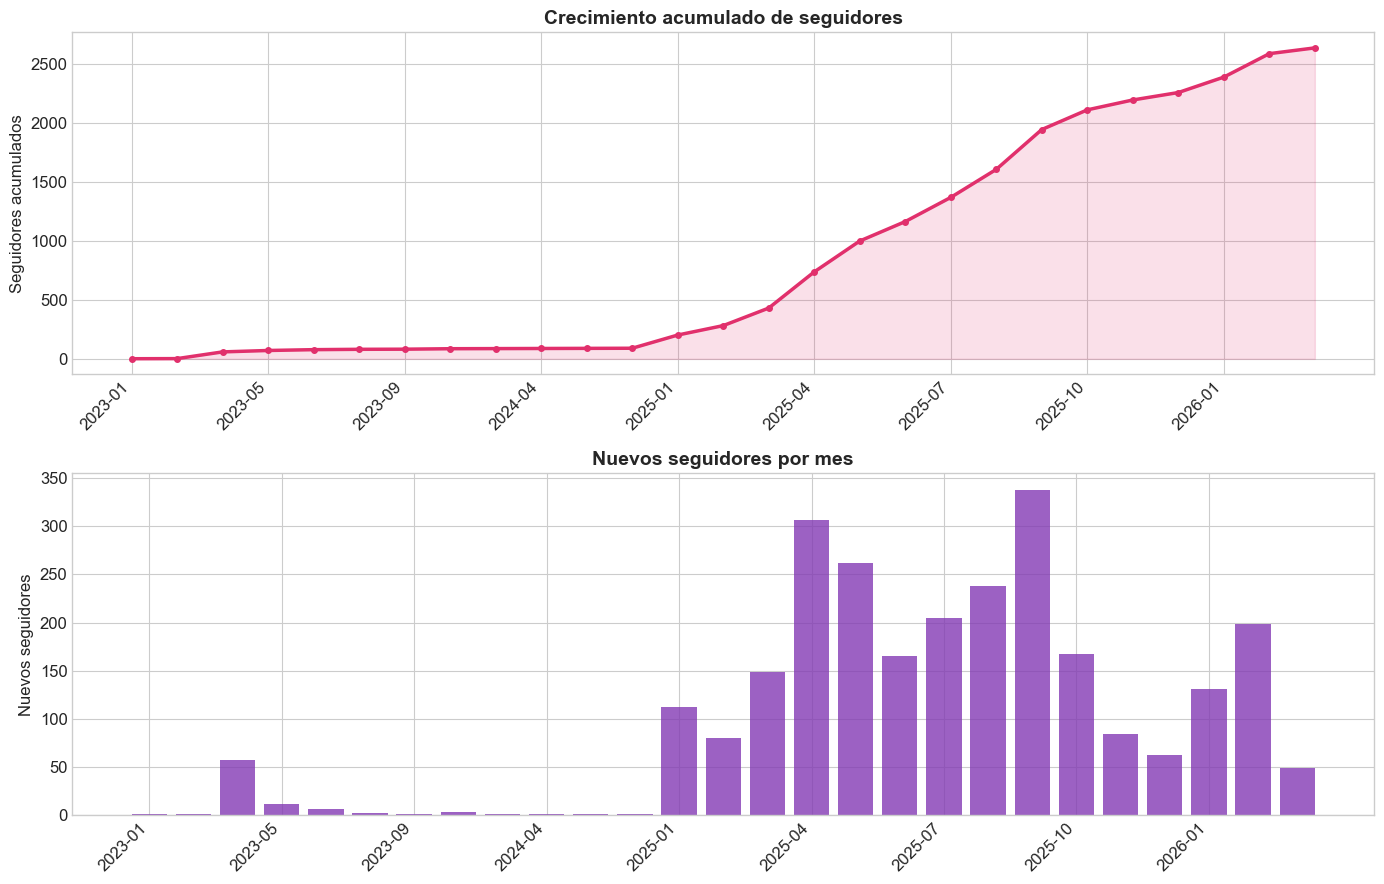


Top 5 meses con más nuevos seguidores:
año_mes  nuevos
2025-09     338
2025-04     307
2025-05     262
2025-08     238
2025-07     205


In [12]:
df_followers['año_mes'] = df_followers['fecha'].dt.to_period('M')
nuevos_por_mes = df_followers.groupby('año_mes').size().reset_index(name='nuevos')
nuevos_por_mes['acumulado'] = nuevos_por_mes['nuevos'].cumsum()
etiquetas = [str(p) for p in nuevos_por_mes['año_mes']]
x = list(range(len(nuevos_por_mes)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.plot(x, nuevos_por_mes['acumulado'].tolist(),
         color='#E1306C', linewidth=2.5, marker='o', markersize=4)
ax1.fill_between(x, nuevos_por_mes['acumulado'].tolist(), alpha=0.15, color='#E1306C')
ax1.set_title('Crecimiento acumulado de seguidores', fontsize=14, fontweight='bold')
ax1.set_ylabel('Seguidores acumulados')
step = max(1, len(etiquetas) // 8)
ax1.set_xticks(list(range(0, len(etiquetas), step)))
ax1.set_xticklabels([etiquetas[i] for i in range(0, len(etiquetas), step)], rotation=45, ha='right')

ax2.bar(x, nuevos_por_mes['nuevos'].tolist(), color='#833AB4', alpha=0.8)
ax2.set_title('Nuevos seguidores por mes', fontsize=14, fontweight='bold')
ax2.set_ylabel('Nuevos seguidores')
ax2.set_xticks(list(range(0, len(etiquetas), step)))
ax2.set_xticklabels([etiquetas[i] for i in range(0, len(etiquetas), step)], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('seguidores_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 meses con más nuevos seguidores:')
print(nuevos_por_mes.nlargest(5, 'nuevos')[['año_mes', 'nuevos']].to_string(index=False))

---
## 4. Análisis: Patrones temporales de publicación

### 4.1 Posts y Reels: día de la semana y hora

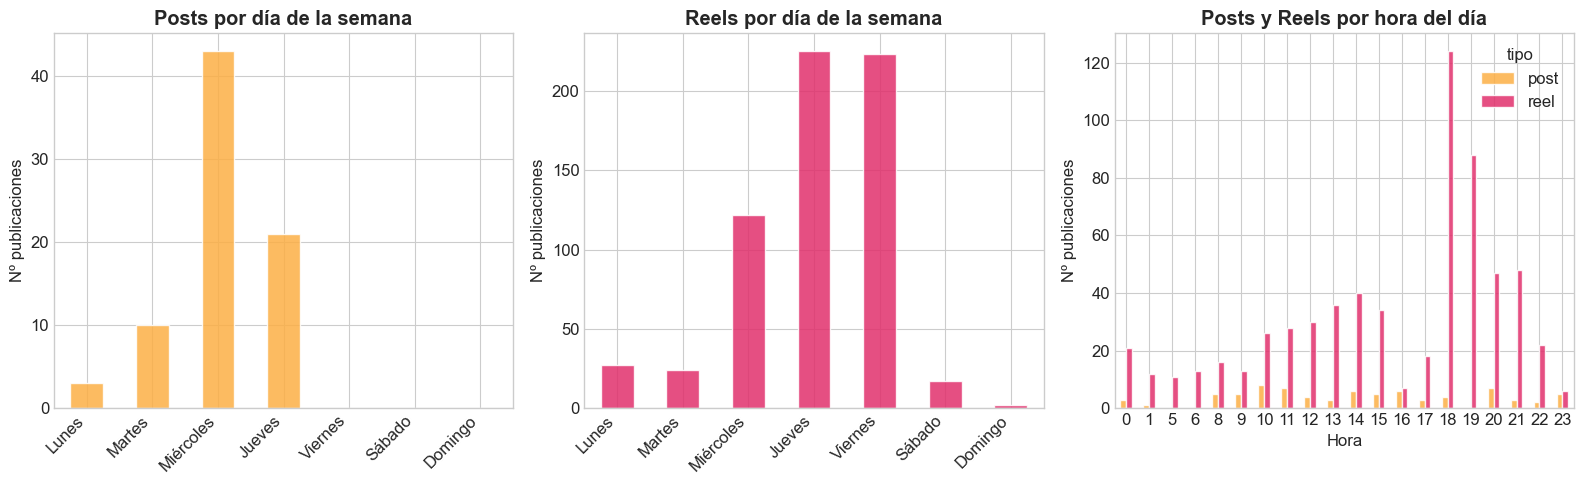

In [13]:
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
           'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}

df_pr = df_contenido[df_contenido['tipo'].isin(['post', 'reel'])].copy()
colores = {'post': '#FCAF45', 'reel': '#E1306C'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, tipo in enumerate(['post', 'reel']):
    subset = df_pr[df_pr['tipo'] == tipo]
    conteo = subset['dia_semana'].value_counts().reindex(dias_orden, fill_value=0)
    conteo.index = [dias_es[d] for d in conteo.index]
    conteo.plot(kind='bar', ax=axes[i], color=colores[tipo], alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{tipo.capitalize()}s por día de la semana', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nº publicaciones')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45, ha='right')

conteo_hora = df_pr.groupby(['hora', 'tipo']).size().unstack(fill_value=0)
conteo_hora.plot(kind='bar', ax=axes[2],
                 color=[colores[c] for c in conteo_hora.columns],
                 alpha=0.85, edgecolor='white')
axes[2].set_title('Posts y Reels por hora del día', fontweight='bold')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('Nº publicaciones')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('patrones_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Heatmap: día × hora

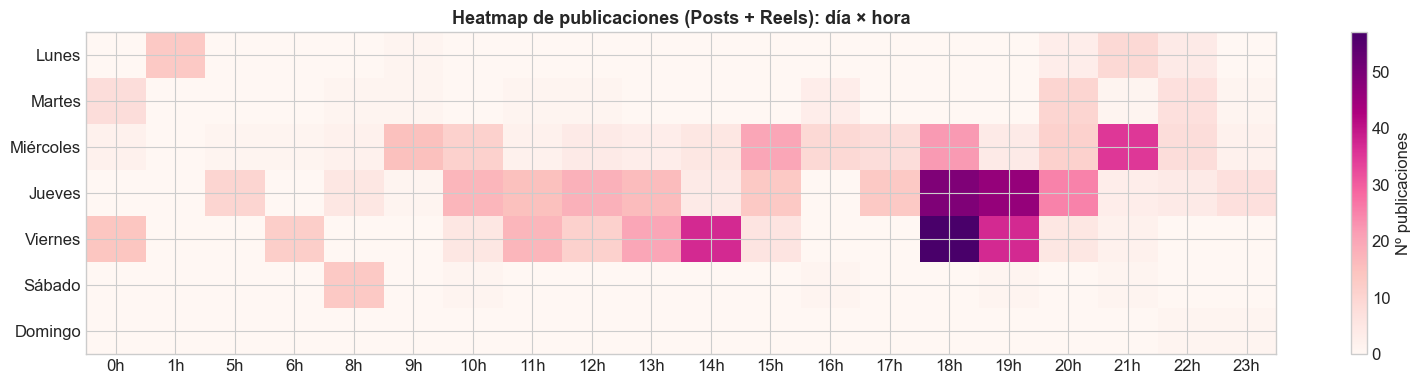

In [14]:
heatmap_data = df_pr.groupby(['dia_semana', 'hora']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(dias_orden, fill_value=0)
heatmap_data.index = [dias_es[d] for d in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(heatmap_data.values, cmap='RdPu', aspect='auto')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels([f'{h}h' for h in heatmap_data.columns])
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Heatmap de publicaciones (Posts + Reels): día × hora', fontsize=13, fontweight='bold')

plt.colorbar(im, ax=ax, label='Nº publicaciones')
plt.tight_layout()
plt.savefig('heatmap_publicaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Frecuencia de publicación mensual

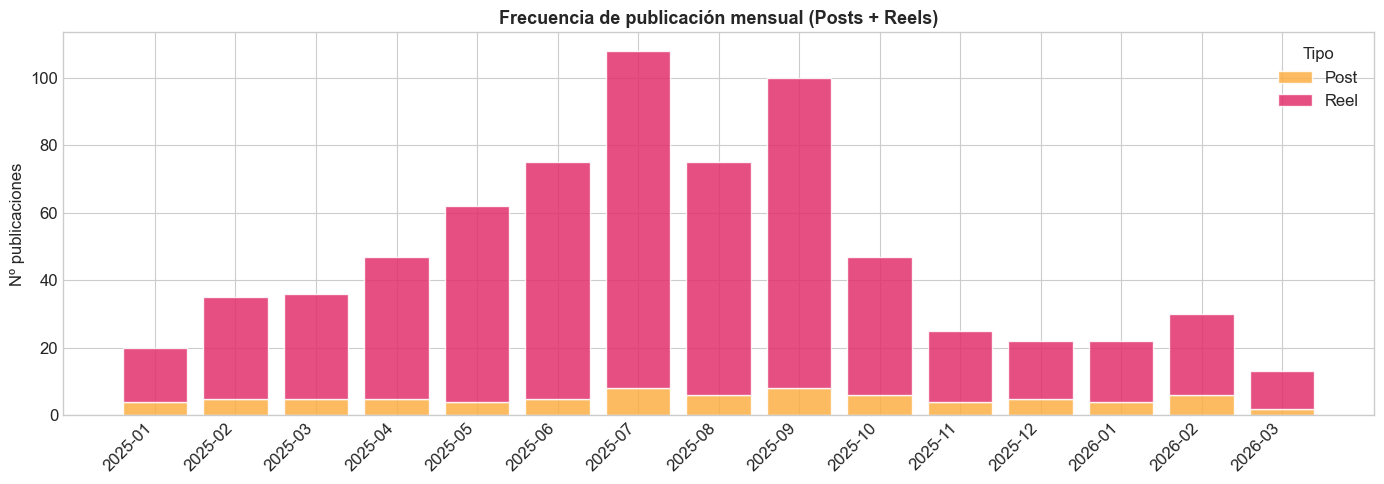

In [15]:
df_pr = df_pr.copy()
df_pr['año_mes'] = df_pr['fecha'].dt.to_period('M')
freq_mensual = df_pr.groupby(['año_mes', 'tipo']).size().unstack(fill_value=0)
etiq_freq = [str(p) for p in freq_mensual.index]
x_freq = list(range(len(freq_mensual)))

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(freq_mensual))
for tipo, color in colores.items():
    if tipo in freq_mensual.columns:
        vals = freq_mensual[tipo].values.astype(float)
        ax.bar(x_freq, vals, bottom=bottom, label=tipo.capitalize(),
               color=color, alpha=0.85, edgecolor='white')
        bottom += vals

step_f = max(1, len(etiq_freq) // 8)
ax.set_xticks(list(range(0, len(etiq_freq), step_f)))
ax.set_xticklabels([etiq_freq[i] for i in range(0, len(etiq_freq), step_f)], rotation=45, ha='right')
ax.set_title('Frecuencia de publicación mensual (Posts + Reels)', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº publicaciones')
ax.legend(title='Tipo')
plt.tight_layout()
plt.savefig('frecuencia_publicacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Análisis: Rendimiento (Insights agregados)

In [16]:
with open(BASE + 'logged_information/past_instagram_insights/content_interactions.json') as f:
    insights_raw = json.load(f)

with open(BASE + 'logged_information/past_instagram_insights/profiles_reached.json') as f:
    reach_raw = json.load(f)

def parse_valor(v):
    if not v:
        return None
    v = str(v).replace(',', '').replace('+', '').replace('%', '').strip()
    try:
        return float(v)
    except:
        return None

insights_data = [
    {k: val['value'] for k, val in item['string_map_data'].items()}
    for item in insights_raw['organic_insights_interactions']
]
df_insights = pd.DataFrame(insights_data)
print('Columnas disponibles:', df_insights.columns.tolist())
df_insights.head()

Columnas disponibles: ['Intervalo de fechas', 'Interacciones con el contenido', 'Diferencia de interacciones con el contenido', 'Interacciones con publicaciones', 'Diferencia de interacciones con las publicaciones', 'Me gusta en publicaciones', 'Comentarios en publicaciones', 'Veces que se compartieron las publicaciones', 'Veces que se guardÃ³ la publicaciÃ³n', 'Interacciones con historias', 'Diferencia de interacciones con las historias', 'Respuestas a historias', 'Interacciones con videos', 'Diferencia de interacciones con los videos', 'Interacciones con reels', 'Diferencia de interacciones con los reels', 'Me gusta en reels', 'Comentarios en reels', 'Veces que se compartieron los reels', 'Veces que se guardaron los reels', 'Interacciones con videos en vivo', 'Diferencia de interacciones con los videos en vivo', 'Cuentas que interactuaron', 'Diferencia de cuentas que interactuaron', 'Cuentas que interactuaron por tipo de seguimiento', 'Interactuaste con un delta% mÃ¡s de cuentas que 

,Intervalo de fechas,Interacciones con el contenido,Diferencia de interacciones con el contenido,Interacciones con publicaciones,Diferencia de interacciones con las publicaciones,Me gusta en publicaciones,Comentarios en publicaciones,Veces que se compartieron las publicaciones,Veces que se guardÃ³ la publicaciÃ³n,Interacciones con historias,...,Me gusta en reels,Comentarios en reels,Veces que se compartieron los reels,Veces que se guardaron los reels,Interacciones con videos en vivo,Diferencia de interacciones con los videos en vivo,Cuentas que interactuaron,Diferencia de cuentas que interactuaron,Cuentas que interactuaron por tipo de seguimiento,Interactuaste con un delta% mÃ¡s de cuentas que no te seguÃ­an en comparaciÃ³n con el perÃ­odo anterior
0,Dec 16 - Mar 15,"4,611",+12.7% vs Sep 17 - Dec 15,"2,150",+27.7% vs Sep 17 - Dec 15,"1,113",7,486,51,368,...,"1,259",8,388,31,0,0% vs Sep 17 - Dec 15,"1,078",+14.8% vs Sep 17 - Dec 15,"Followers: 64.6%, Non-followers: 35.4%",+1.8% vs Sep 17 - Dec 15


Período: Dec 16 - Mar 15

  Me gusta en publicaciones: 1,113
  Comentarios en publicaciones: 7
  Veces que se compartieron las publicaciones: 486
  Interacciones con historias: 368


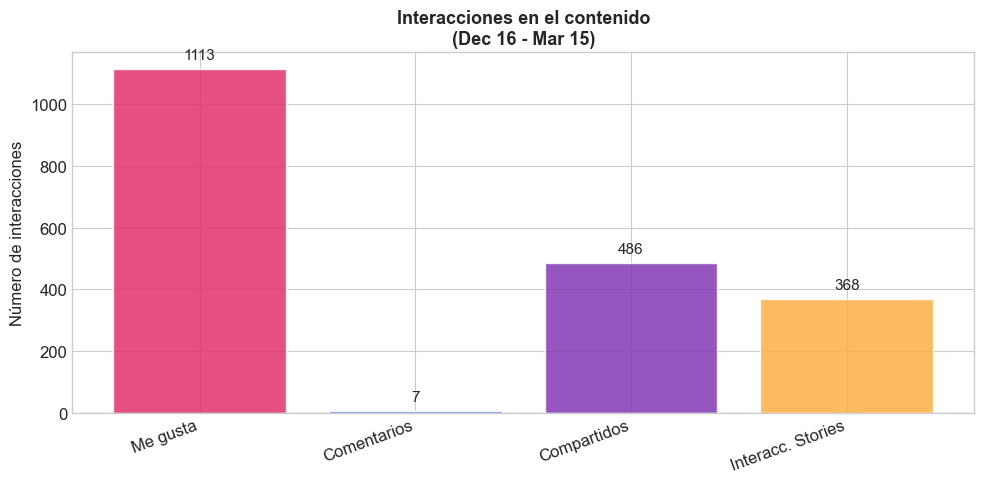

In [17]:
ultimo = df_insights.iloc[0]
print(f"Período: {ultimo.get('Intervalo de fechas', 'N/A')}\n")

candidatas = [
    ('Me gusta en publicaciones', 'Me gusta'),
    ('Comentarios en publicaciones', 'Comentarios'),
    ('Veces que se compartieron las publicaciones', 'Compartidos'),
    ('Veces que se guardó la publicación', 'Guardados'),
    ('Interacciones con historias', 'Interacc. Stories'),
    ('Interacciones con Reels', 'Interacc. Reels'),
]

metricas_plot = {}
for col, nombre in candidatas:
    if col in ultimo.index:
        val = parse_valor(ultimo[col])
        if val is not None and val > 0:
            metricas_plot[nombre] = val
            print(f'  {col}: {ultimo[col]}')

colores_metrics = ['#E1306C', '#405DE6', '#833AB4', '#FCAF45', '#FD1D1D', '#C13584']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(list(metricas_plot.keys()), list(metricas_plot.values()),
              color=colores_metrics[:len(metricas_plot)], alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.0f', padding=5, fontsize=11)
ax.set_title(f"Interacciones en el contenido\n({ultimo.get('Intervalo de fechas', 'último período')})",
             fontsize=13, fontweight='bold')
ax.set_ylabel('Número de interacciones')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('metricas_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

Período: Dec 16 - Mar 15
Cuentas alcanzadas: 50,577
Seguidores: 4.7% | No seguidores: 95.3%


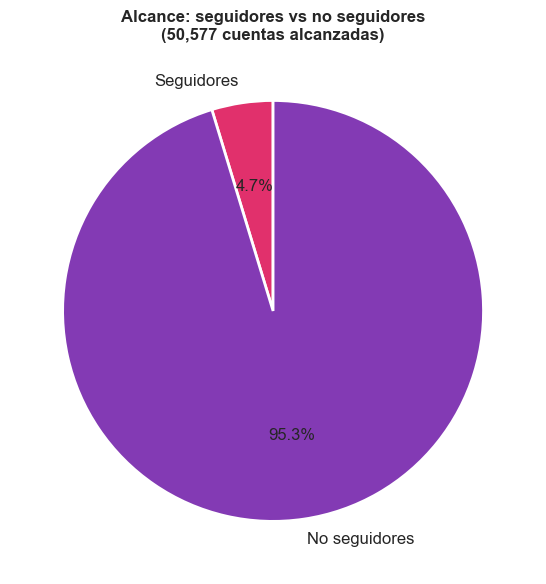

In [18]:
# Alcance: seguidores vs no seguidores
reach_data = [
    {k: val['value'] for k, val in item['string_map_data'].items()}
    for item in reach_raw['organic_insights_reach']
]
df_reach = pd.DataFrame(reach_data)
r = df_reach.iloc[0]

seg_pct = parse_valor(r.get('Seguidores', '0'))
noseg_pct = parse_valor(r.get('No seguidores', '0'))
alcanzadas = parse_valor(r.get('Cuentas alcanzadas', '0'))

print(f"Período: {r.get('Intervalo de fechas', 'N/A')}")
print(f"Cuentas alcanzadas: {int(alcanzadas):,}")
print(f"Seguidores: {seg_pct}% | No seguidores: {noseg_pct}%")

if seg_pct and noseg_pct:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie([seg_pct, noseg_pct],
           labels=['Seguidores', 'No seguidores'],
           colors=['#E1306C', '#833AB4'],
           autopct='%1.1f%%', startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'Alcance: seguidores vs no seguidores\n({int(alcanzadas):,} cuentas alcanzadas)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('alcance_pie.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Resumen final

In [19]:
fecha_min = df_contenido['fecha'].min().date()
fecha_max = df_contenido['fecha'].max().date()
dias_activo = (pd.Timestamp(str(fecha_max)) - pd.Timestamp(str(fecha_min))).days

print('=' * 50)
print('RESUMEN DEL EDA - INSTAGRAM')
print('=' * 50)
print(f'\n📸 Contenido publicado:')
print(f'   Posts:   {len(df_posts)}')
print(f'   Reels:   {len(df_reels)}')
print(f'   Stories: {len(df_stories)}')
print(f'   TOTAL:   {len(df_contenido)}')
print(f'\n👥 Audiencia:')
print(f'   Seguidores: {len(df_followers):,}')
print(f'   Siguiendo:  {len(df_following):,}')
print(f'   Ratio: {len(df_followers)/len(df_following):.2f}')
print(f'\n📅 Período registrado:')
print(f'   {fecha_min} → {fecha_max} ({dias_activo} días)')
print(f'\n📊 Métricas del último período ({ultimo.get("Intervalo de fechas", "")}):')  
for k, v in metricas_plot.items():
    print(f'   {k}: {int(v):,}')
print(f'\n🌍 Alcance:')
print(f'   Cuentas alcanzadas: {int(alcanzadas):,}')
print(f'   Seguidores: {seg_pct}% | No seguidores: {noseg_pct}%')

RESUMEN DEL EDA - INSTAGRAM

📸 Contenido publicado:
   Posts:   77
   Reels:   640
   Stories: 1306
   TOTAL:   2023

👥 Audiencia:
   Seguidores: 2,639
   Siguiendo:  509
   Ratio: 5.18

📅 Período registrado:
   2023-05-02 → 2026-03-14 (1047 días)

📊 Métricas del último período (Dec 16 - Mar 15):
   Me gusta: 1,113
   Comentarios: 7
   Compartidos: 486
   Interacc. Stories: 368

🌍 Alcance:
   Cuentas alcanzadas: 50,577
   Seguidores: 4.7% | No seguidores: 95.3%
